In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import ReduceLROnPlateau
from keras.preprocessing.image import ImageDataGenerator
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [6]:
from os.path import join as pjoin
DATA_DIR = pjoin("data", "ascii-sign-language")

In [ ]:
### Disclaimer: some code / architechture inspired by these notebooks on Sign Language Classification 
### https://www.kaggle.com/code/databeru/sign-language-mnist-classifier-acc-99-78
### https://www.kaggle.com/code/madz2000/cnn-using-keras-100-accuracy

In [4]:
# Script to import data while reducing memory usage, inspired by work from Guillaume Martin
# https://www.kaggle.com/code/gemartin/load-data-reduce-memory-usage

def reduce_mem_usage(df):
    """ Iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df


def import_data(file):
    df = pd.read_csv(file, parse_dates=True, keep_date_col=True)
    df = reduce_mem_usage(df)
    return df

In [7]:
train_df = import_data(pjoin(DATA_DIR, 'sign_mnist_train.csv' ))
test_df = import_data(pjoin(DATA_DIR, 'test.csv'))

Memory usage of dataframe is 164.43 MB
Memory usage after optimization is: 41.08 MB
Decreased by 75.0%
Memory usage of dataframe is 35.91 MB
Memory usage after optimization is: 8.98 MB
Decreased by 75.0%


In [8]:
# Transform test_df into the right format

image_a_df = test_df.iloc[:, [0] + list(range(1, 785))]
image_b_df = test_df.iloc[:, [0] + list(range(785, test_df.shape[1]))]
columns = train_df.drop('label', axis=1).columns
image_a_df.columns = [image_a_df.columns[0]] + list(columns)
image_b_df.columns = [image_b_df.columns[0]] + list(columns)
test_df = pd.concat([image_a_df, image_b_df], axis=0)

In [9]:
dims = int((train_df.shape[1] - 1)**0.5)
print(f'Number of images in the training set: {train_df.shape[0]}')
print(f'Number of images in the test set: {test_df.shape[0]//2}')
print(f'Shape of the images: {dims} x {dims}')

Number of images in the training set: 27455
Number of images in the test set: 3000
Shape of the images: 28 x 28


In [10]:
alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
mapping_letter = {}

for i, l in enumerate(alphabet):
    mapping_letter[l] = i
mapping_letter = {v:k for k,v in mapping_letter.items()}

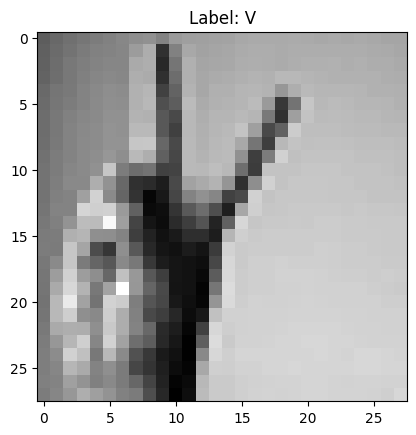

In [11]:
def to_image(array, label = True):
    array = np.array(array)
    start_idx = 1 if label else 0
    return array[start_idx:].reshape(28,28).astype(float)
        
# Display a random image
img_index = np.random.choice(list(range(0,train_df.shape[0])))
img = to_image(train_df.iloc[img_index])
label = mapping_letter[train_df.iloc[img_index, 0]]

plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

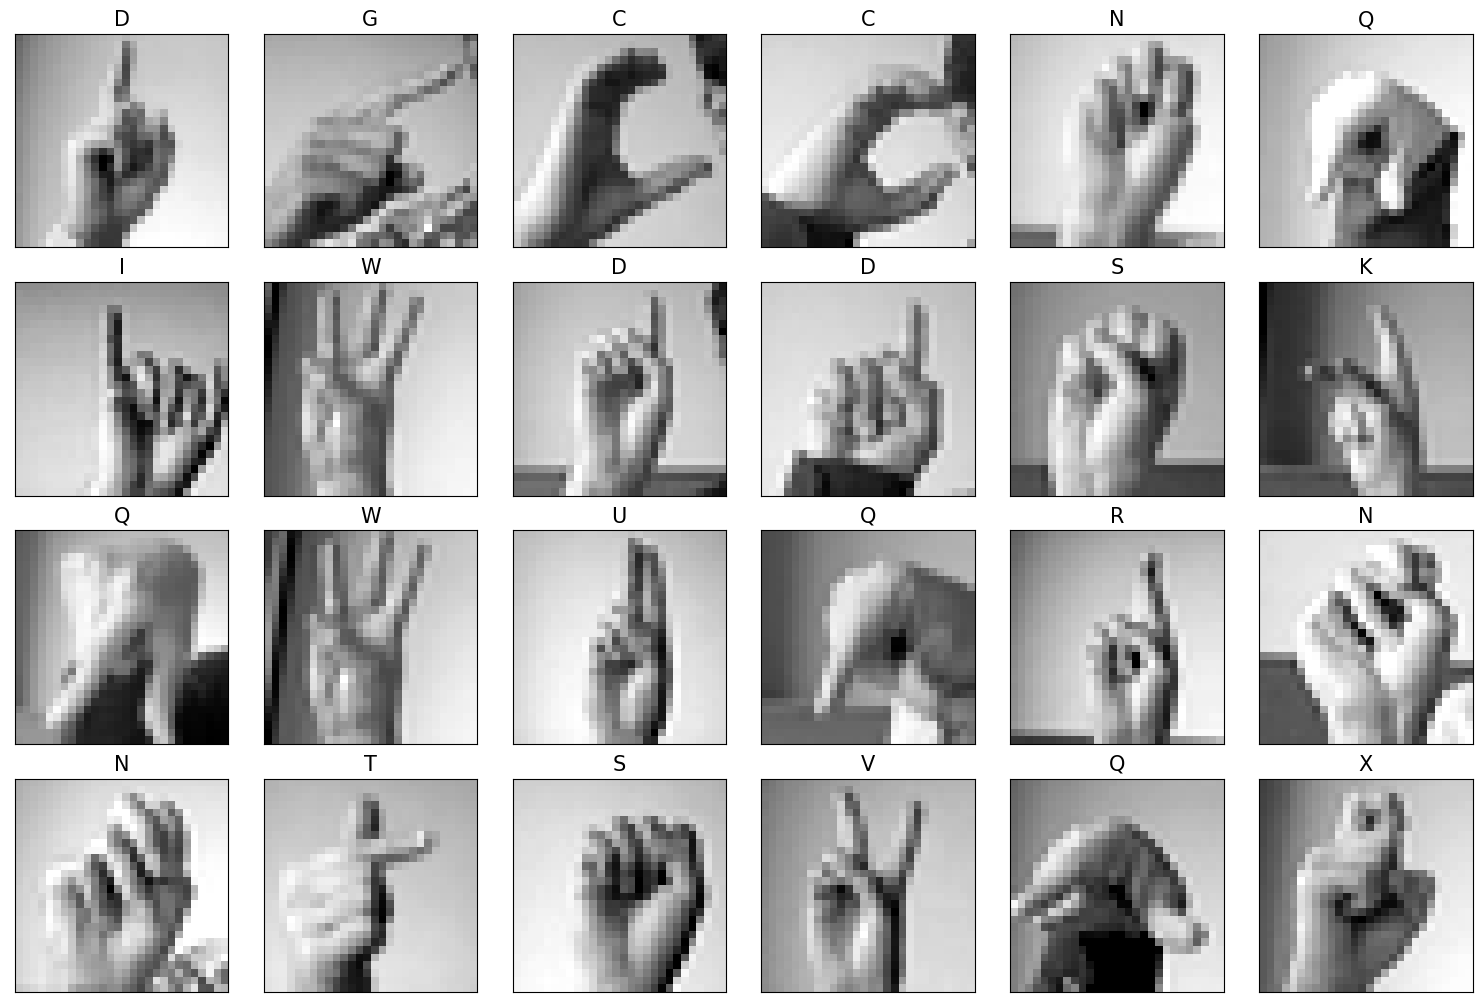

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(15, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    img = to_image(train_df.iloc[i])
    ax.imshow(img, cmap = 'gray')
    title = mapping_letter[train_df.label[i]]
    ax.set_title(title, fontsize = 15)
plt.tight_layout(pad=0.5)
plt.show()

## 2. Machine Learning / Neural Networks

### 2.1 CNN

In [13]:
train_df_original = train_df.copy()
val_index = int(train_df.shape[0]*0.25)

train_df = train_df_original.iloc[val_index:]
val_df = train_df_original.iloc[:val_index]

y_train = train_df['label']
y_val = val_df['label']

X_train = train_df.drop('label',axis = 1).values.reshape(train_df.shape[0], 28, 28, 1)
X_val = val_df.drop('label',axis = 1).values.reshape(val_df.shape[0], 28, 28, 1)
X_test = test_df.drop('id', axis=1).values.reshape(test_df.shape[0], 28, 28, 1)

In [14]:
X_train.shape, X_val.shape, X_test.shape

((20592, 28, 28, 1), (6863, 28, 28, 1), (6000, 28, 28, 1))

In [15]:
# Data augmentation
generator = ImageDataGenerator(rescale=1./255,
                               rotation_range=10,
                               zoom_range=0.10,
                               width_shift_range=0.1,
                               height_shift_range=0.1,
                               shear_range=0.1,
                               horizontal_flip=False,
                               fill_mode="nearest")

X_train_flow = generator.flow(X_train, y_train, batch_size=32)
X_val_flow = generator.flow(X_val, y_val, batch_size=32)

In [16]:
model = Sequential([Conv2D(filters=32,  kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
                    BatchNormalization(),
                    MaxPool2D(2,2, padding='same'),
                    Conv2D(filters=128,  kernel_size=(3,3), activation="relu"),
                    MaxPool2D(2,2, padding='same'),
                    Conv2D(filters=512, kernel_size=(3,3), activation="relu"),
                    MaxPool2D(2,2, padding='same'),
                    Flatten(),
                    Dense(units=1024, activation="relu"),                 
                    Dense(units=256, activation="relu"),
                    Dropout(0.5),
                    Dense(units=25, activation="softmax")
])

model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 26, 26, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 128)       36992     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 128)         0         
 g2D)                                                            
                                                     

In [18]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', 
    patience = 3, 
    verbose=1,
    factor=0.5, 
    min_lr=0.00001
)

history = model.fit(X_train_flow, 
                    validation_data=X_val_flow, 
                    #epochs=150,
                    epochs=10,
                    callbacks=[
                        tf.keras.callbacks.EarlyStopping(
                        monitor='val_loss',
                        patience=5,
                        restore_best_weights=True), 
                        learning_rate_reduction
                    ])

Epoch 1/10
644/644 [==============================] - 24s 37ms/step - loss: 1.3107e-04 - accuracy: 1.0000 - val_loss: 1.7279e-06 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/10
644/644 [==============================] - 22s 34ms/step - loss: 8.3367e-04 - accuracy: 0.9999 - val_loss: 7.5176e-06 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/10
644/644 [==============================] - 22s 35ms/step - loss: 8.3626e-04 - accuracy: 0.9999 - val_loss: 3.1080e-05 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/10
644/644 [==============================] - 22s 35ms/step - loss: 1.0764e-04 - accuracy: 1.0000 - val_loss: 3.1309e-06 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/10
644/644 [==============================] - 23s 35ms/step - loss: 3.0346e-04 - accuracy: 1.0000 - val_loss: 1.1806e-06 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 6/10
644/644 [==============================] - 22s 35ms/step - loss: 6.5745e-05 - accuracy: 1.0000 - val_loss: 3.1961e-04 - val_accuracy: 0.9999 - l

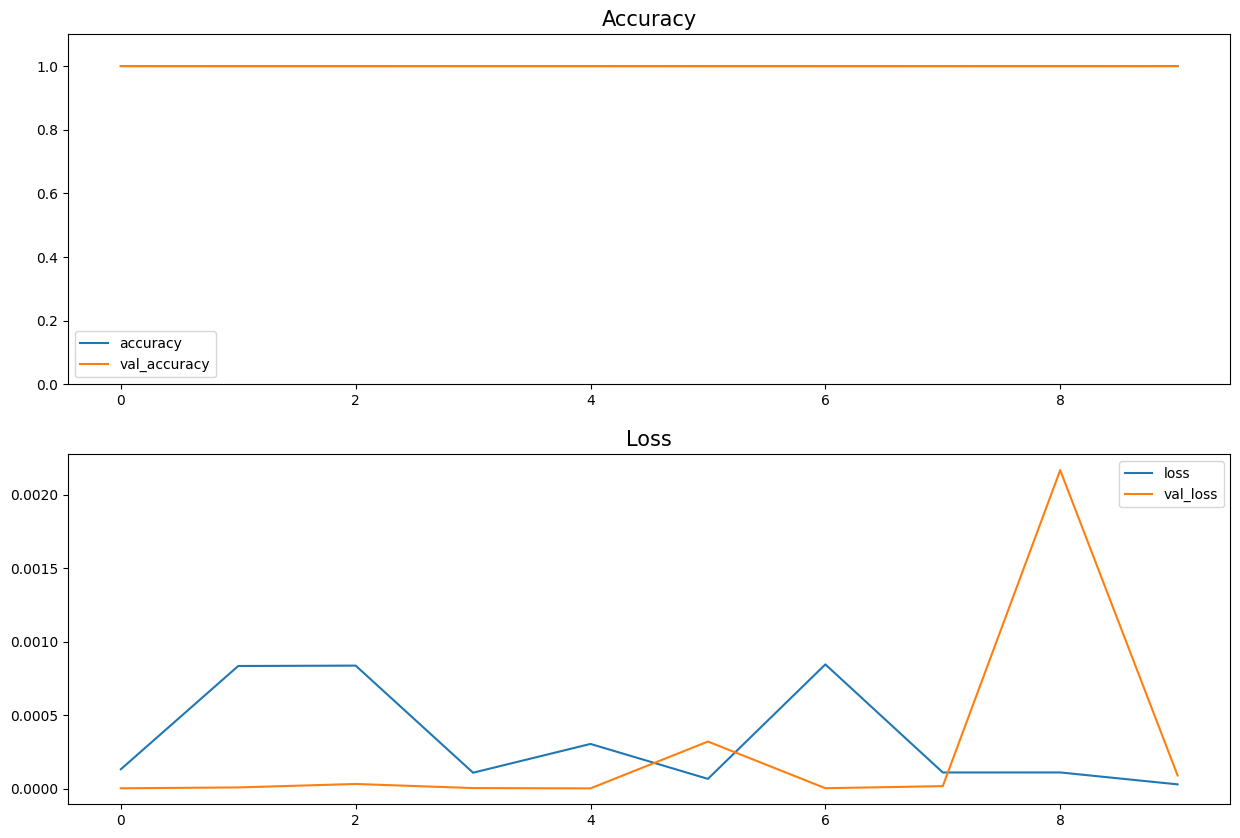

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
ax = axes.flat

pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy", fontsize = 15)
ax[0].set_ylim(0,1.1)

pd.DataFrame(history.history)[['loss','val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss", fontsize = 15)
plt.show()

### 2.2 Random Forest

In [20]:
y_train = train_df['label']
y_val = val_df['label']

X_train_tree = train_df.drop('label',axis = 1)
X_val_tree = val_df.drop('label',axis = 1)
X_test_tree = test_df.drop('id', axis=1)

In [21]:
%%time

#Baseline

rf = RandomForestClassifier(random_state=5, max_depth=25, n_estimators=20)
                        
rf.fit(X_train_tree, y_train)
acc = accuracy_score((y_val), (rf.predict(X_val_tree)))
print("The classification accuracy on test set of the RF: {:.7%}".format(acc))

The classification accuracy on test set of the RF: 98.8197581%
CPU times: total: 5.78 s
Wall time: 5.86 s


In [22]:
individual_trees = rf.estimators_
average_depth = sum(tree.get_depth() for tree in individual_trees) / len(individual_trees)

print("Average Depth of Trees:", average_depth)

Average Depth of Trees: 25.0


### 2.3 XGBoost

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
%%time

#Baseline
le = LabelEncoder()
y_train = le.fit_transform(y_train)
xgbm = xgb.XGBClassifier(random_state=5)

                        
xgbm.fit(X_train_tree, y_train)

y_pred = le.inverse_transform(xgbm.predict(X_val_tree))
y_train = train_df['label']
acc = accuracy_score((y_val), (y_pred))
print("The classification accuracy on test set of the XGB: {:.7%}".format(acc))

The classification accuracy on test set of the XGB: 99.0820341%
CPU times: total: 52min 28s
Wall time: 4min 13s


### 2.4 SVM

In [26]:
%%time

#Baseline

svm_model = SVC(random_state=5, kernel='rbf', C=1.0, gamma='scale')

svm_model.fit(X_train_tree, y_train)

acc_svm = accuracy_score(y_val, svm_model.predict(X_val_tree))
print("The classification accuracy on test set of the SVM: {:.7%}".format(acc_svm))

The classification accuracy on test set of the SVM: 99.9708582%
CPU times: total: 1min 5s
Wall time: 1min 6s


### 2.5 k-NN

In [27]:
%%time

#Baseline

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_tree, y_train)

acc_knn = accuracy_score(y_val, knn_model.predict(X_val_tree))
print("The classification accuracy on test set of the KNN: {:.7%}".format(acc_knn))

The classification accuracy on test set of the KNN: 99.4608772%
CPU times: total: 46.9 s
Wall time: 9.15 s


## 3. Submission

In [28]:
# Predict the label of the test_images
pred = rf.predict(X_test_tree)
#pred = np.argmax(pred,axis=1)

In [29]:
def convert_to_char(ascii_sum):
    if ascii_sum > 122:
        return chr(ascii_sum - 65)
    return chr(ascii_sum)

def convert_predictions_to_chars(predictions):
    return [str(convert_to_char(65 + pred)) for pred in predictions]

def convert_predictions_to_chars2(predictions):
    return [str(convert_to_char(pred)) for pred in predictions]

In [30]:
def ascii_manipulation(pred):
    char_predictions = convert_predictions_to_chars(pred)
    pred_ascii = [ord(i) for i in char_predictions]
    combined_predictions = [pred_ascii[i] + pred_ascii[i + 3000] for i in range(3000)]
    char_predictions_final = convert_predictions_to_chars2(combined_predictions)
    return char_predictions_final

In [31]:
char_predictions_final = ascii_manipulation(pred)
print(char_predictions_final)

['M', 'U', 'G', 'S', '\\', 'g', '`', 'F', 'T', 'Y', 'P', 'V', 'L', 'A', 'A', 'H', 'g', 'Y', 'S', '_', 'U', 'Q', 'Q', 'j', 'a', 'I', 'S', 'W', 'R', ']', '`', 'W', '[', 'W', 'D', 'F', 'Z', 'd', 'M', 'V', 'J', '\\', 'M', '\\', '^', 'c', 'Q', 'I', 'G', 'O', '^', 'g', '\\', 'P', '_', 'K', 'Q', 'G', 'H', 'N', 'F', 'W', 'l', 'T', 'H', 'R', 'c', 'b', ']', 'i', '^', 'B', 'M', 'Y', 'H', '[', '`', 'M', '_', 'c', 'Z', 'W', 'b', 'U', 'N', 'X', 'U', 'O', ']', 'R', 'H', 'Y', 'S', 'G', 'S', 'W', '^', 'M', 'W', 'E', 'W', 'O', 'E', 'k', 'M', '\\', 'Z', 'K', 'W', 'c', 'L', 'M', 'H', 'Z', 'U', 'J', 'J', ']', 'U', 'g', '`', 'O', 'T', 'i', 'K', 'L', 'V', 'L', 'U', ']', 'R', '`', '_', 'M', 'k', 'T', 'X', 'W', 'Y', 'T', 'V', 'g', 'R', 'a', 'P', 'D', 'c', 'k', 'Q', 'U', 'T', 'W', '^', 'O', 'L', '[', 'g', '\\', 'M', 'V', 'N', 'W', 'Z', 'M', 'F', 'c', 'a', ']', 'I', 'Y', '[', 'F', 'K', 'Y', 'X', 'R', 'b', 'f', 'Q', 'X', 'W', 'W', 'T', '[', 'Z', '[', ']', 'e', 'X', 'F', 'G', 'H', 'B', ']', 'I', 'P', 'M', 'T', 'K'

In [33]:
current_time = datetime.now()
formatted_time = current_time.strftime("%Y-%m-%d_%H-%M")
sample_submission = pd.read_csv("sample_submission.csv")
sample_submission["label"] = char_predictions_final
note = "tree_model_v2"

sample_submission.to_csv(f"submissions/submission_{formatted_time}_{note}.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'sample_submission.csv'